# Network Propagation by Module
- seed = 각 셀타입별 WGCNA **Module1 / Module2** 전체 유전자 (DEG 필터 없음)
- 파라미터: restart_prob=0.1, STRING combined_score>=700 (by_celltype 노트북과 동일)
- 9 cell types x 2 modules = 18 plots


In [11]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

sys.path.insert(0, '/data1/project/yeonu/065_multi_rna/propagation')
from network_propagation import Walker

BASE_DIR = '/data1/project/yeonu/065_multi_rna'
WGCNA_DIR = os.path.join(BASE_DIR, 'WGCNA_80/results_output')
NET_PATH = os.path.join(BASE_DIR, 'propagation/string_network.txt')

RESTART_PROB = 0.1

# ---------- Fixed font sizing (by_celltype.ipynb 와 동일) ----------
TITLE_FS = 14
LABEL_FS = 12
TICK_FS = 11
LEGEND_FS = 10
ANNOT_FS = 9

CELL_TYPES = [
    'Hepatocytes', 'T_Cells', 'Mesenchymal', 'Macrophages', 'NK_Cells',
    'Endothelial_Cells', 'Plasma_Cells', 'DCs', 'B_Cells',
]

# ---------- 1. STRING 네트워크 로드 (1회) ----------
print('Loading STRING network...')
walker = Walker(NET_PATH, constantWeight=True)
all_nodes = sorted(walker.OG.nodes())
N_NET = len(all_nodes)
print(f'Network nodes: {N_NET}')


def get_module_genes(ct):
    '''WGCNA .p 로드 -> eigengene clustering(2개) -> Module1/2 유전자 집합 반환'''
    p_path = os.path.join(WGCNA_DIR, ct, f'{ct}_Network.p')
    with open(p_path, 'rb') as f:
        pywgcna = pickle.load(f)
    MEs = pywgcna.datME
    gene_info = pd.read_csv(
        os.path.join(WGCNA_DIR, ct, 'hub_genes', 'all_genes_wgcna_info.csv'),
        index_col=0
    )
    module_colors = [c.replace('ME', '') for c in MEs.columns]
    dist = pdist(MEs.T, metric='correlation')
    Z = linkage(dist, method='average')
    labels = fcluster(Z, t=2, criterion='maxclust')
    c1 = [module_colors[i] for i in range(len(module_colors)) if labels[i] == 1]
    c2 = [module_colors[i] for i in range(len(module_colors)) if labels[i] == 2]
    return {
        'Module1': set(gene_info[gene_info['moduleColors'].isin(c1)].index),
        'Module2': set(gene_info[gene_info['moduleColors'].isin(c2)].index),
    }


def run_rwr(seed_genes):
    seed2w = {g: 1.0 for g in seed_genes if g in walker.dic_node2idx}
    if not seed2w:
        return pd.DataFrame(columns=['Gene', 'NP_Score']), 0
    result = walker.run_exp(seed2w, RESTART_PROB, normalize=True)
    df = pd.DataFrame([(node, score) for node, score, _ in result],
                      columns=['Gene', 'NP_Score'])
    return df, len(seed2w)


# ---------- 2. 18개 (celltype x module) RWR 사전 실행 + 전역 axis 계산 ----------
print('\nPre-computing 18 RWR results...')
MODULE_GENES = {}
NP_CACHE = {}  # {ct: {module: (df, n_seed_in_net)}}

max_logp = 0.0
max_nonseed_score = 0.0

for ct in CELL_TYPES:
    mods = get_module_genes(ct)
    MODULE_GENES[ct] = mods
    NP_CACHE[ct] = {}
    for mod_name, seed_set in mods.items():
        df, n_seed = run_rwr(seed_set)
        NP_CACHE[ct][mod_name] = (df, n_seed, seed_set)
        if len(df) == 0:
            continue
        N = len(df)
        max_logp = max(max_logp, -np.log10(1.0 / N + 1e-10))
        ns = df[~df['Gene'].isin(seed_set)]['NP_Score']
        if len(ns):
            max_nonseed_score = max(max_nonseed_score, float(ns.max()))
        print(f'  {ct:20s} {mod_name}: module={len(seed_set):5d}, in_network={n_seed:5d}')

XLIM_MAX = max_logp * 1.05
YLIM_MAX = max_nonseed_score * 1.10
print(f'\nGlobal axis limits -> xlim=(0, {XLIM_MAX:.3f}), ylim=(0, {YLIM_MAX:.5f})')
print('  (ylim = non-seed NP_Score max x 1.10 -- seed outlier 제외)')


# ---------- 3. Plot 함수 ----------
def plot_np(ct, mod_name):
    df, n_seed, seed_set = NP_CACHE[ct][mod_name]
    if len(df) == 0:
        print(f'--- {ct} {mod_name}: SKIP (seed not in network) ---')
        return
    df = df.sort_values('NP_Score', ascending=False).reset_index(drop=True)
    df['is_Seed'] = df['Gene'].apply(lambda x: 'Yes' if x in seed_set else 'No')
    df['Rank'] = np.arange(1, len(df) + 1)
    df['P_value'] = df['Rank'] / len(df)
    df['log_p'] = -np.log10(df['P_value'] + 1e-10)

    N = len(df)
    SCORE_CUTOFF = 1.0 / N

    df['Category'] = 'Other genes'
    df.loc[df['NP_Score'] >= SCORE_CUTOFF, 'Category'] = 'Above 1/N'
    df.loc[df['is_Seed'] == 'Yes', 'Category'] = 'Seed (Module)'

    color_palette = {'Seed (Module)': 'red', 'Above 1/N': 'green', 'Other genes': '#e0e0e0'}

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.set_style('whitegrid')
    for cat in ['Other genes', 'Above 1/N', 'Seed (Module)']:
        sub = df[df['Category'] == cat]
        ax.scatter(sub['log_p'], sub['NP_Score'], c=color_palette[cat],
                   label=f'{cat} ({len(sub)})', alpha=0.6, s=50)

    ax.axhline(y=SCORE_CUTOFF, color='black', linestyle='--',
               label=f'1/N = {SCORE_CUTOFF:.6f}')

    top_non_seed = df[df['is_Seed'] == 'No'].nlargest(10, 'NP_Score')
    for _, row in top_non_seed.iterrows():
        ax.text(row['log_p'], row['NP_Score'], row['Gene'],
                fontsize=ANNOT_FS, fontweight='bold')

    ax.set_title(f'{ct} - {mod_name}', fontsize=TITLE_FS, fontweight='bold')
    ax.set_xlabel('-log10(p-value)', fontsize=LABEL_FS)
    ax.set_ylabel('NP Score', fontsize=LABEL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.set_xlim(0, XLIM_MAX)
    ax.set_ylim(0, YLIM_MAX)
    ax.legend(fontsize=LEGEND_FS, loc='upper left')
    plt.tight_layout()
    plt.show()

    candidates = df[(df['NP_Score'] >= SCORE_CUTOFF) & (df['is_Seed'] == 'No')]
    print(f'Module genes: {len(seed_set)} | in-network seeds: {n_seed} | '
          f'novel candidates (>=1/N): {len(candidates)}')
    print('Top 20:')
    print(df.head(20)[['Rank', 'Gene', 'NP_Score', 'is_Seed']].to_string(index=False))


print('\nReady.')


Loading STRING network...
Network nodes: 16201

Pre-computing 18 RWR results...
81 iterated
  Hepatocytes          Module1: module=  491, in_network=  469
91 iterated
  Hepatocytes          Module2: module=  850, in_network=  794
91 iterated
  T_Cells              Module1: module= 1238, in_network= 1166
96 iterated
  T_Cells              Module2: module=  103, in_network=   97
89 iterated
  Mesenchymal          Module1: module= 1289, in_network= 1213
67 iterated
  Mesenchymal          Module2: module=   52, in_network=   50
90 iterated
  Macrophages          Module1: module= 1156, in_network= 1082
64 iterated
  Macrophages          Module2: module=  185, in_network=  181
91 iterated
  NK_Cells             Module1: module= 1037, in_network=  976
61 iterated
  NK_Cells             Module2: module=  304, in_network=  287
92 iterated
  Endothelial_Cells    Module1: module=  790, in_network=  736
80 iterated
  Endothelial_Cells    Module2: module=  551, in_network=  527
89 iterated
  Plasma

---
## 1. Hepatocytes


--------------------------------------------------------------------------------


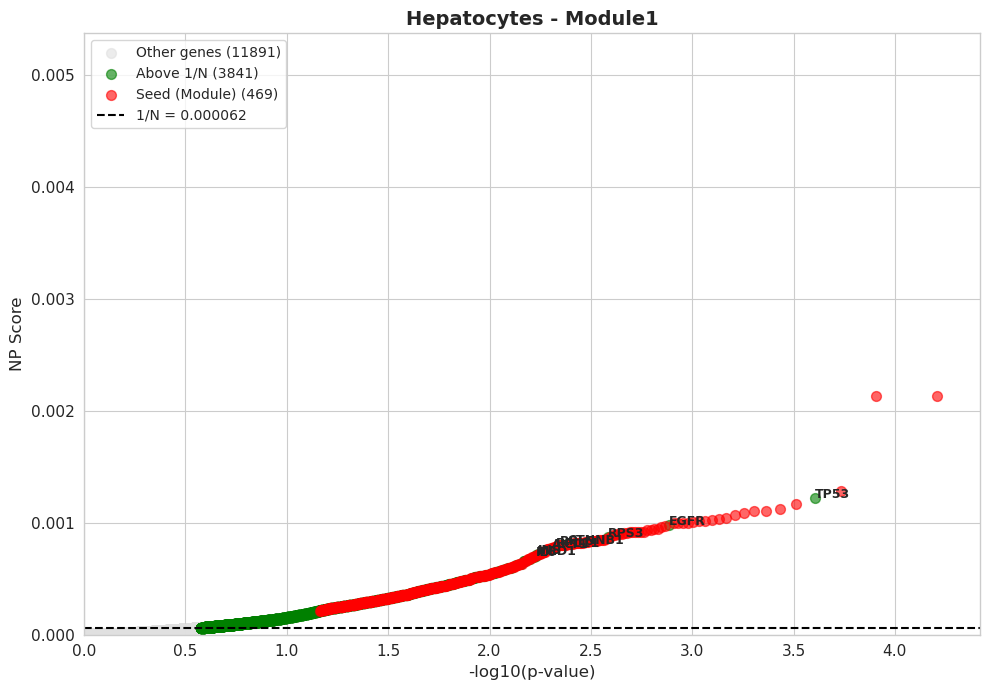

Module genes: 491 | in-network seeds: 469 | novel candidates (>=1/N): 3841
Top 20:
 Rank     Gene  NP_Score is_Seed
    1 TMEM176A  0.002132     Yes
    2 TMEM176B  0.002132     Yes
    3   RPS27A  0.001282     Yes
    4     TP53  0.001225      No
    5    UBA52  0.001171     Yes
    6     MPC2  0.001122     Yes
    7    RPS18  0.001107     Yes
    8      FAU  0.001106     Yes
    9      ALB  0.001088     Yes
   10    RPS11  0.001067     Yes
   11     RPS9  0.001046     Yes
   12     ACTB  0.001032     Yes
   13    RPS19  0.001026     Yes
   14     RPL4  0.001018     Yes
   15     RPS6  0.001017     Yes
   16   RPL23A  0.001009     Yes
   17    RPS16  0.000999     Yes
   18    RPS23  0.000998     Yes
   19     RPS2  0.000996     Yes
   20    RPL23  0.000996     Yes

--------------------------------------------------------------------------------


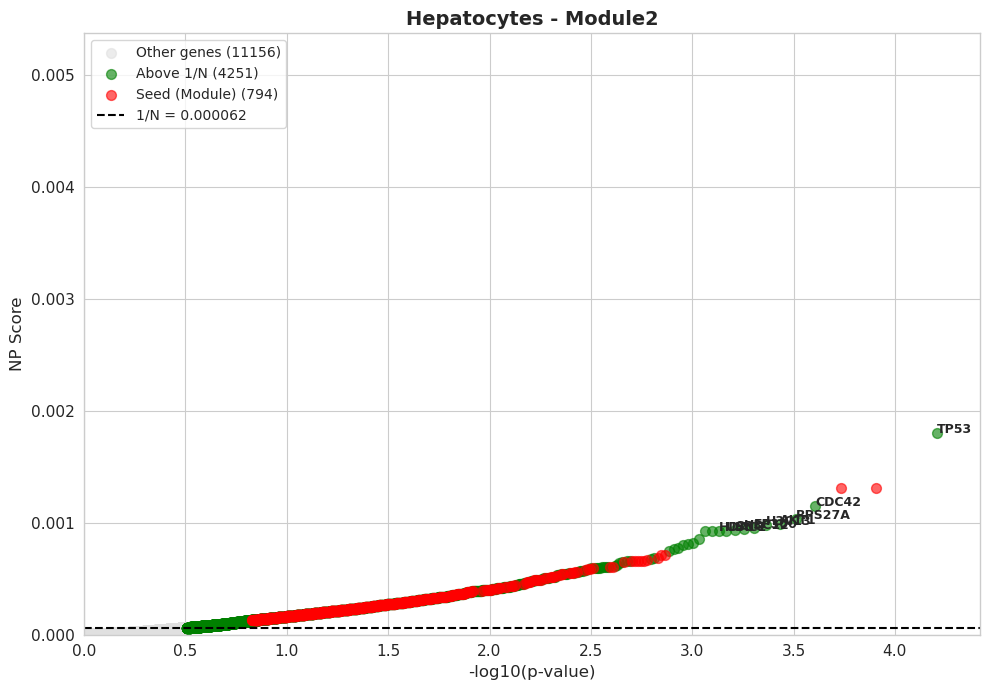

Module genes: 850 | in-network seeds: 794 | novel candidates (>=1/N): 4251
Top 20:
 Rank     Gene  NP_Score is_Seed
    1     TP53  0.001805      No
    2   CTNNB1  0.001311     Yes
    3     EGFR  0.001310     Yes
    4    CDC42  0.001146      No
    5   RPS27A  0.001035      No
    6     AKT1  0.000988      No
    7    H3C13  0.000976      No
    8    EP300  0.000951      No
    9    H3C12  0.000947      No
   10      SRC  0.000939      No
   11      UBC  0.000930      No
   12    HDAC1  0.000927      No
   13     ACTB  0.000927      No
   14    UBA52  0.000923      No
   15     H4C6  0.000857      No
   16      MYC  0.000822      No
   17      TNF  0.000812      No
   18     RHOA  0.000800      No
   19    H3-3B  0.000778      No
   20 HSP90AA1  0.000768      No


In [12]:
CT = 'Hepatocytes'
for mod in ['Module1', 'Module2']:
    print(f'\n{"-"*80}')
    plot_np(CT, mod)

---
## 2. T_Cells


--------------------------------------------------------------------------------


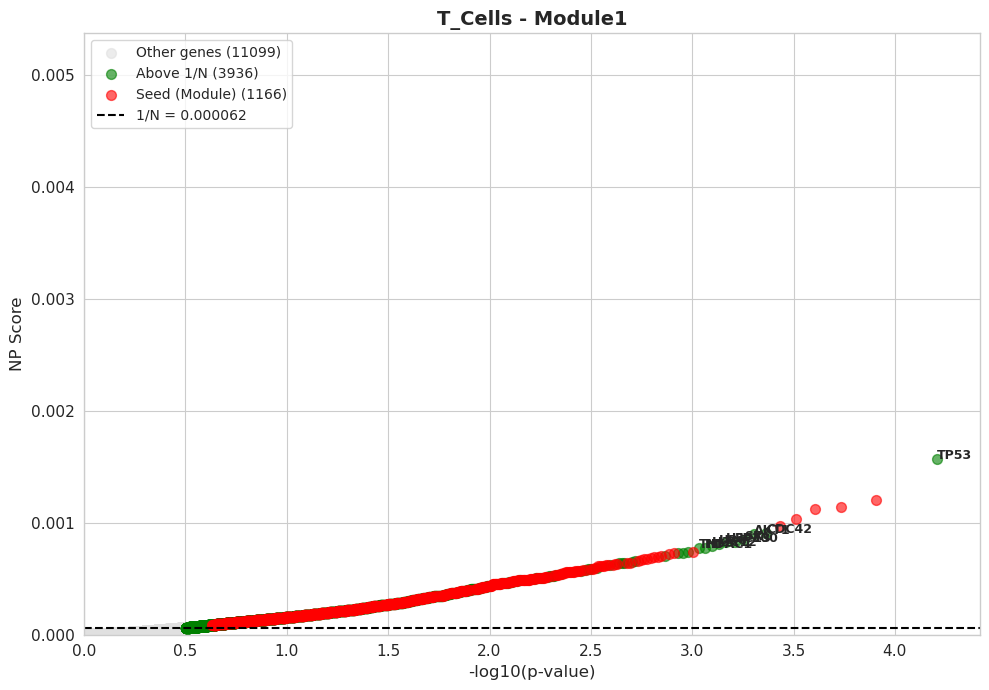

Module genes: 1238 | in-network seeds: 1166 | novel candidates (>=1/N): 3936
Top 20:
 Rank     Gene  NP_Score is_Seed
    1     TP53  0.001574      No
    2     EGFR  0.001199     Yes
    3   RPS27A  0.001145     Yes
    4   CTNNB1  0.001123     Yes
    5    UBA52  0.001034     Yes
    6     ACTB  0.000976     Yes
    7    CDC42  0.000913      No
    8     AKT1  0.000896      No
    9      SRC  0.000845      No
   10    EP300  0.000827      No
   11    H3C13  0.000825      No
   12      UBC  0.000811      No
   13    H3C12  0.000795      No
   14    HDAC1  0.000775      No
   15      TNF  0.000773      No
   16      FAU  0.000743     Yes
   17 HSP90AA1  0.000737      No
   18     H4C6  0.000731      No
   19      MYC  0.000729      No
   20      ALB  0.000727     Yes

--------------------------------------------------------------------------------


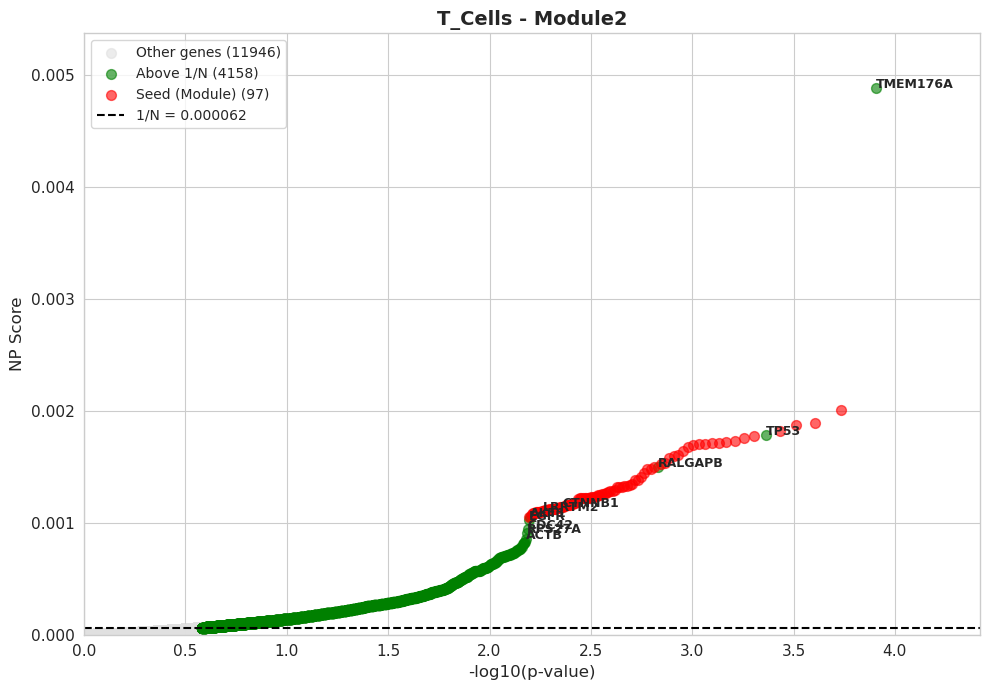

Module genes: 103 | in-network seeds: 97 | novel candidates (>=1/N): 4158
Top 20:
 Rank     Gene  NP_Score is_Seed
    1 TMEM176B  0.005426     Yes
    2 TMEM176A  0.004884      No
    3 HSP90AA1  0.002003     Yes
    4 HSP90AB1  0.001891     Yes
    5      JUN  0.001877     Yes
    6     RHOA  0.001823     Yes
    7     TP53  0.001780      No
    8      UBC  0.001776     Yes
    9   MT-CO1  0.001759     Yes
   10   MT-CO2  0.001729     Yes
   11   MT-CO3  0.001724     Yes
   12   MT-ND1  0.001714     Yes
   13   MT-ND4  0.001709     Yes
   14   MT-ND3  0.001707     Yes
   15   MT-ND2  0.001702     Yes
   16    HSPA8  0.001692     Yes
   17   MT-ND5  0.001680     Yes
   18   MT-CYB  0.001645     Yes
   19  MT-ND4L  0.001606     Yes
   20   MT-ND6  0.001592     Yes


In [3]:
CT = 'T_Cells'
for mod in ['Module1', 'Module2']:
    print(f'\n{"-"*80}')
    plot_np(CT, mod)

---
## 3. Mesenchymal


--------------------------------------------------------------------------------


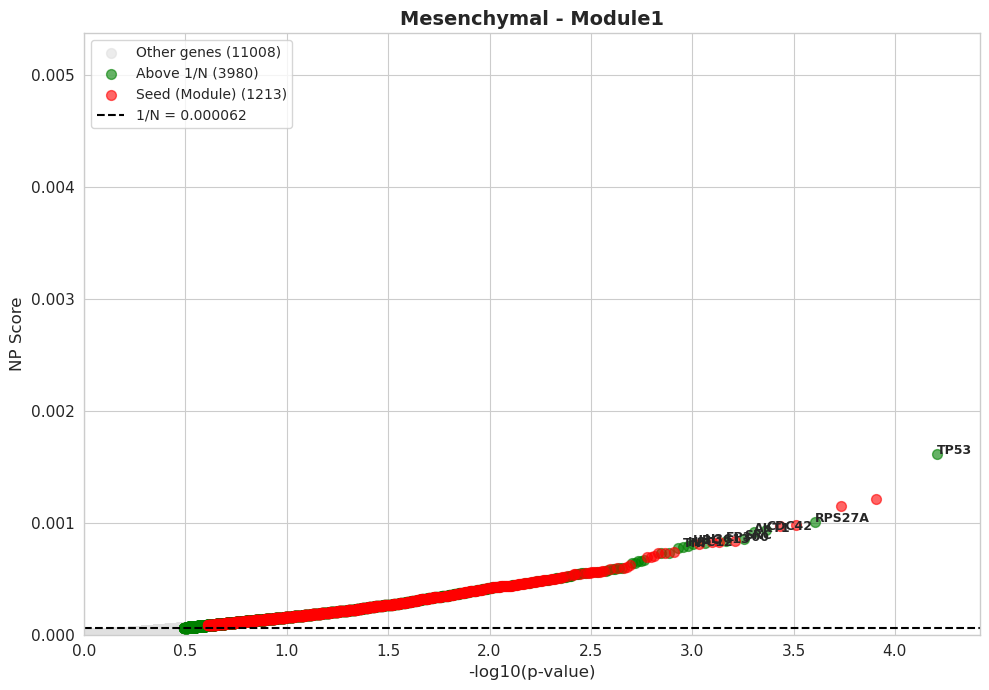

Module genes: 1289 | in-network seeds: 1213 | novel candidates (>=1/N): 3980
Top 20:
 Rank     Gene  NP_Score is_Seed
    1     TP53  0.001610      No
    2     EGFR  0.001211     Yes
    3   CTNNB1  0.001149     Yes
    4   RPS27A  0.001008      No
    5    UBA52  0.000980     Yes
    6     ACTB  0.000972     Yes
    7    CDC42  0.000935      No
    8     AKT1  0.000915      No
    9      SRC  0.000857      No
   10 HSP90AA1  0.000841     Yes
   11    EP300  0.000835      No
   12 TMEM176A  0.000824     Yes
   13 TMEM176B  0.000824     Yes
   14    H3C13  0.000819      No
   15     RHOA  0.000808     Yes
   16      UBC  0.000806      No
   17    H3C12  0.000790      No
   18      TNF  0.000782      No
   19    HDAC1  0.000776      No
   20      ALB  0.000739     Yes

--------------------------------------------------------------------------------


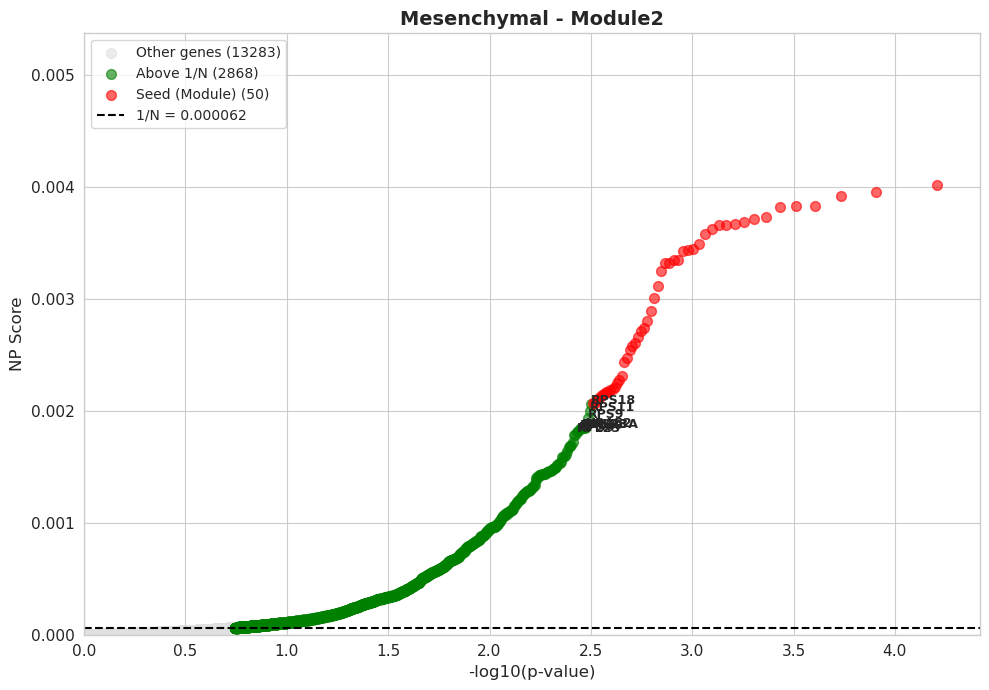

Module genes: 52 | in-network seeds: 50 | novel candidates (>=1/N): 2868
Top 20:
 Rank   Gene  NP_Score is_Seed
    1 RPS27A  0.004016     Yes
    2    FAU  0.003952     Yes
    3   RPS3  0.003918     Yes
    4   RPL5  0.003828     Yes
    5  RPS16  0.003828     Yes
    6  RPL11  0.003819     Yes
    7   RPS5  0.003728     Yes
    8  RPS3A  0.003710     Yes
    9  RPL35  0.003683     Yes
   10  RPS24  0.003673     Yes
   11  RPS13  0.003663     Yes
   12  RPS28  0.003662     Yes
   13  RPLP0  0.003628     Yes
   14  RPL27  0.003583     Yes
   15  RPL30  0.003493     Yes
   16  RPS4X  0.003449     Yes
   17   RPSA  0.003432     Yes
   18  RPS26  0.003428     Yes
   19  RPL24  0.003348     Yes
   20 RPS15A  0.003344     Yes


In [4]:
CT = 'Mesenchymal'
for mod in ['Module1', 'Module2']:
    print(f'\n{"-"*80}')
    plot_np(CT, mod)

---
## 4. Macrophages


--------------------------------------------------------------------------------


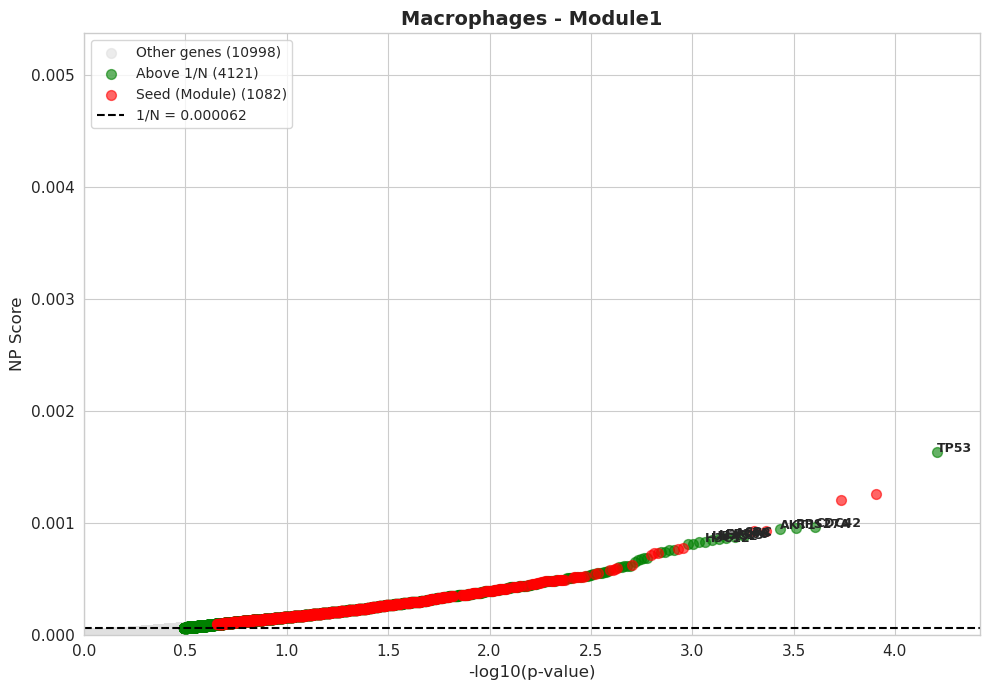

Module genes: 1156 | in-network seeds: 1082 | novel candidates (>=1/N): 4121
Top 20:
 Rank     Gene  NP_Score is_Seed
    1     TP53  0.001630      No
    2     EGFR  0.001253     Yes
    3   CTNNB1  0.001207     Yes
    4    CDC42  0.000961      No
    5   RPS27A  0.000954      No
    6     AKT1  0.000942      No
    7 TMEM176A  0.000924     Yes
    8 TMEM176B  0.000924     Yes
    9      SRC  0.000883      No
   10     ACTB  0.000876      No
   11    EP300  0.000866      No
   12    H3C13  0.000858      No
   13    UBA52  0.000848      No
   14    H3C12  0.000828      No
   15      UBC  0.000825      No
   16    HDAC1  0.000811      No
   17      TNF  0.000806      No
   18      ALB  0.000776     Yes
   19      FN1  0.000770     Yes
   20      MYC  0.000760      No

--------------------------------------------------------------------------------


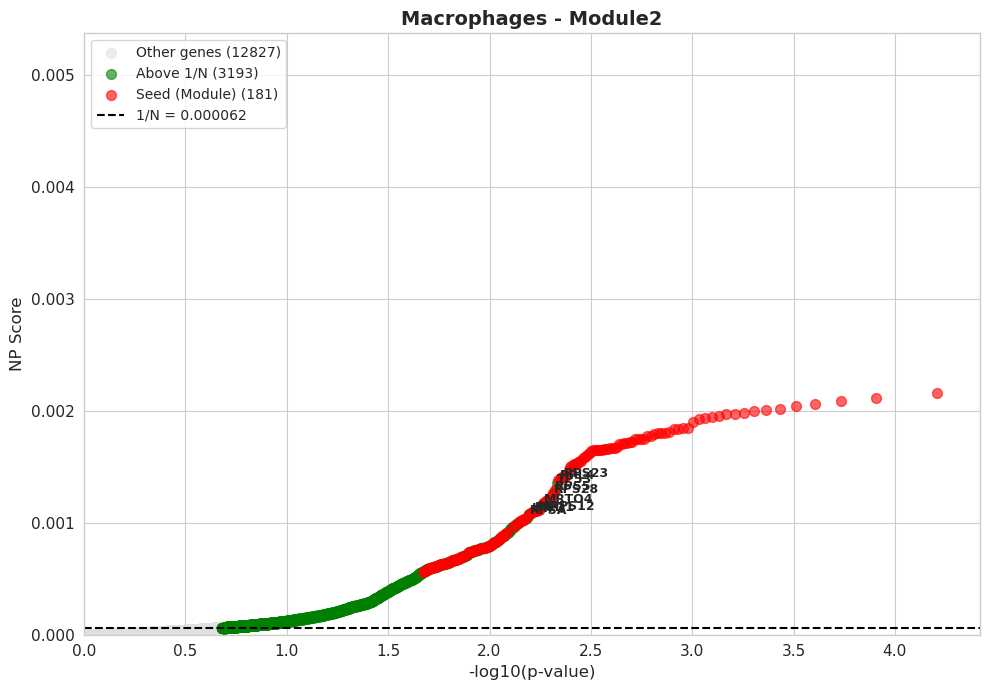

Module genes: 185 | in-network seeds: 181 | novel candidates (>=1/N): 3193
Top 20:
 Rank   Gene  NP_Score is_Seed
    1 RPS27A  0.002161     Yes
    2  RPS18  0.002111     Yes
    3   RPS3  0.002088     Yes
    4  RPS11  0.002060     Yes
    5  RPS19  0.002041     Yes
    6  UBA52  0.002017     Yes
    7    FAU  0.002006     Yes
    8   RPS9  0.001996     Yes
    9   RPL5  0.001985     Yes
   10 RPL23A  0.001975     Yes
   11  RPL11  0.001971     Yes
   12  RPL23  0.001954     Yes
   13  RPS16  0.001942     Yes
   14   RPS2  0.001938     Yes
   15   RPS6  0.001923     Yes
   16  RPS15  0.001896     Yes
   17  RPL35  0.001846     Yes
   18  RPS3A  0.001844     Yes
   19   RPL8  0.001840     Yes
   20  RPS14  0.001837     Yes


In [5]:
CT = 'Macrophages'
for mod in ['Module1', 'Module2']:
    print(f'\n{"-"*80}')
    plot_np(CT, mod)

---
## 5. NK_Cells


--------------------------------------------------------------------------------


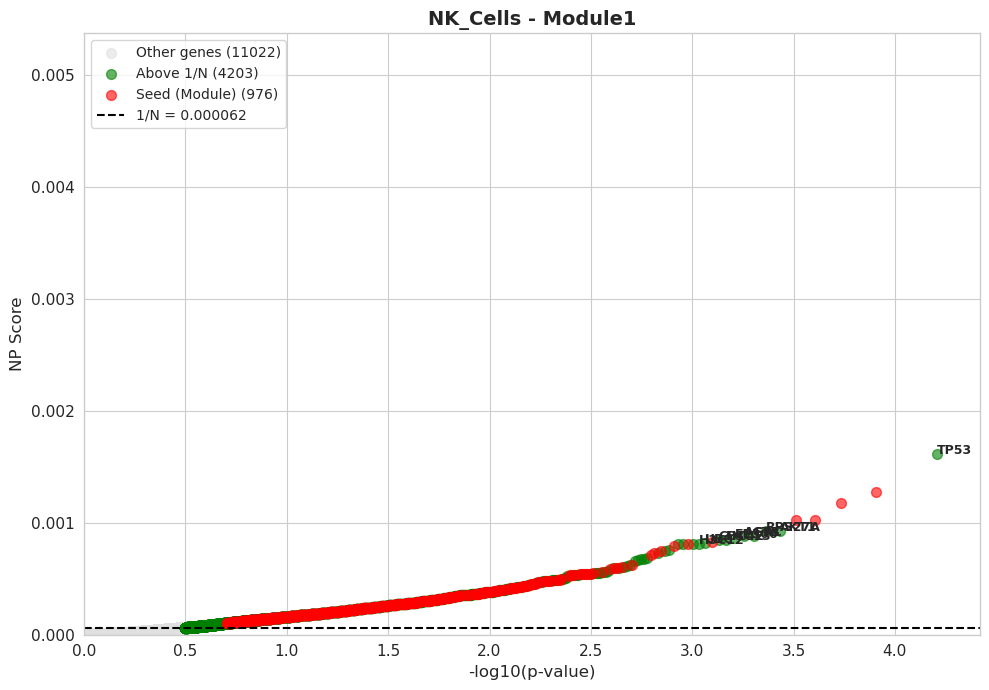

Module genes: 1037 | in-network seeds: 976 | novel candidates (>=1/N): 4203
Top 20:
 Rank     Gene  NP_Score is_Seed
    1     TP53  0.001611      No
    2     EGFR  0.001271     Yes
    3   CTNNB1  0.001176     Yes
    4 TMEM176A  0.001025     Yes
    5 TMEM176B  0.001025     Yes
    6     AKT1  0.000930      No
    7   RPS27A  0.000922      No
    8      SRC  0.000884      No
    9     ACTB  0.000879      No
   10    EP300  0.000863      No
   11    H3C13  0.000845      No
   12    CDC42  0.000844      No
   13     RHOA  0.000832     Yes
   14      UBC  0.000823      No
   15    H3C12  0.000814      No
   16      TNF  0.000814      No
   17      ALB  0.000812     Yes
   18    UBA52  0.000812      No
   19    HDAC1  0.000810      No
   20      FN1  0.000791     Yes

--------------------------------------------------------------------------------


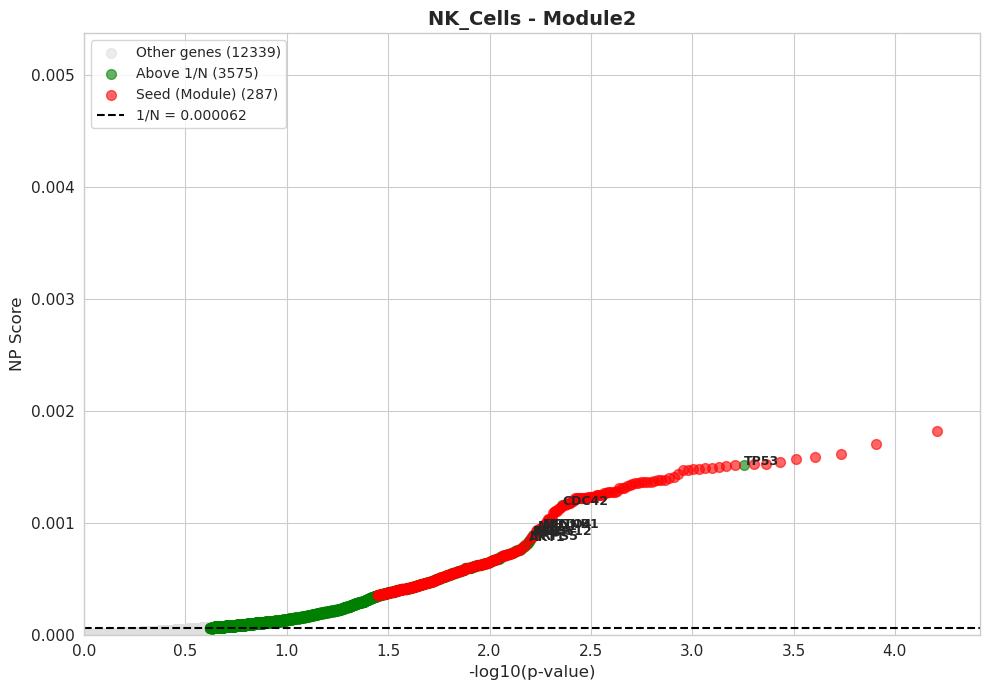

Module genes: 304 | in-network seeds: 287 | novel candidates (>=1/N): 3575
Top 20:
 Rank   Gene  NP_Score is_Seed
    1 RPS27A  0.001822     Yes
    2  UBA52  0.001706     Yes
    3  RPS18  0.001615     Yes
    4   RPS3  0.001584     Yes
    5  RPS11  0.001568     Yes
    6    FAU  0.001546     Yes
    7   RPS9  0.001529     Yes
    8  RPS19  0.001523     Yes
    9   TP53  0.001517      No
   10   RPL5  0.001512     Yes
   11   RPS6  0.001508     Yes
   12 RPL23A  0.001501     Yes
   13   RPL4  0.001491     Yes
   14  RPL11  0.001489     Yes
   15  RPL23  0.001479     Yes
   16  RPS23  0.001477     Yes
   17  RPS16  0.001471     Yes
   18   RPS2  0.001470     Yes
   19  RPS15  0.001433     Yes
   20   RPS5  0.001406     Yes


In [6]:
CT = 'NK_Cells'
for mod in ['Module1', 'Module2']:
    print(f'\n{"-"*80}')
    plot_np(CT, mod)

---
## 6. Endothelial_Cells


--------------------------------------------------------------------------------


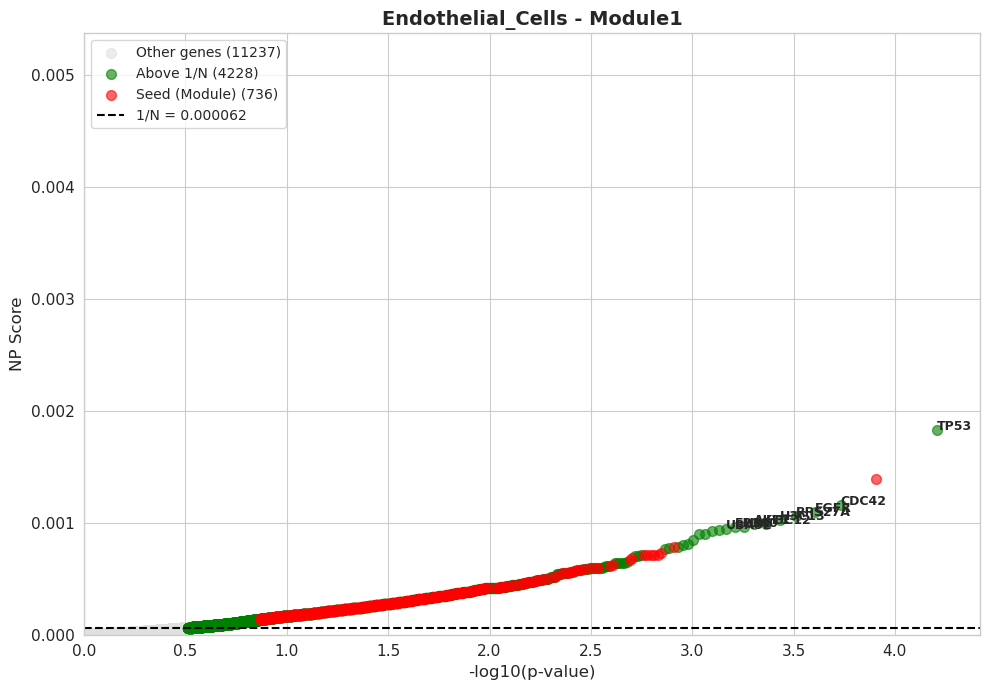

Module genes: 790 | in-network seeds: 736 | novel candidates (>=1/N): 4228
Top 20:
 Rank     Gene  NP_Score is_Seed
    1     TP53  0.001828      No
    2   CTNNB1  0.001389     Yes
    3    CDC42  0.001157      No
    4     EGFR  0.001097      No
    5   RPS27A  0.001063      No
    6    H3C13  0.001023      No
    7    H3C12  0.000990      No
    8     AKT1  0.000985      No
    9      UBC  0.000966      No
   10    EP300  0.000965      No
   11    UBA52  0.000946      No
   12     ACTB  0.000938      No
   13    HDAC1  0.000930      No
   14     H4C6  0.000898      No
   15      SRC  0.000897      No
   16     RHOA  0.000845      No
   17    H3-3B  0.000812      No
   18      TNF  0.000801      No
   19 HSP90AA1  0.000786      No
   20    STAT3  0.000780     Yes

--------------------------------------------------------------------------------


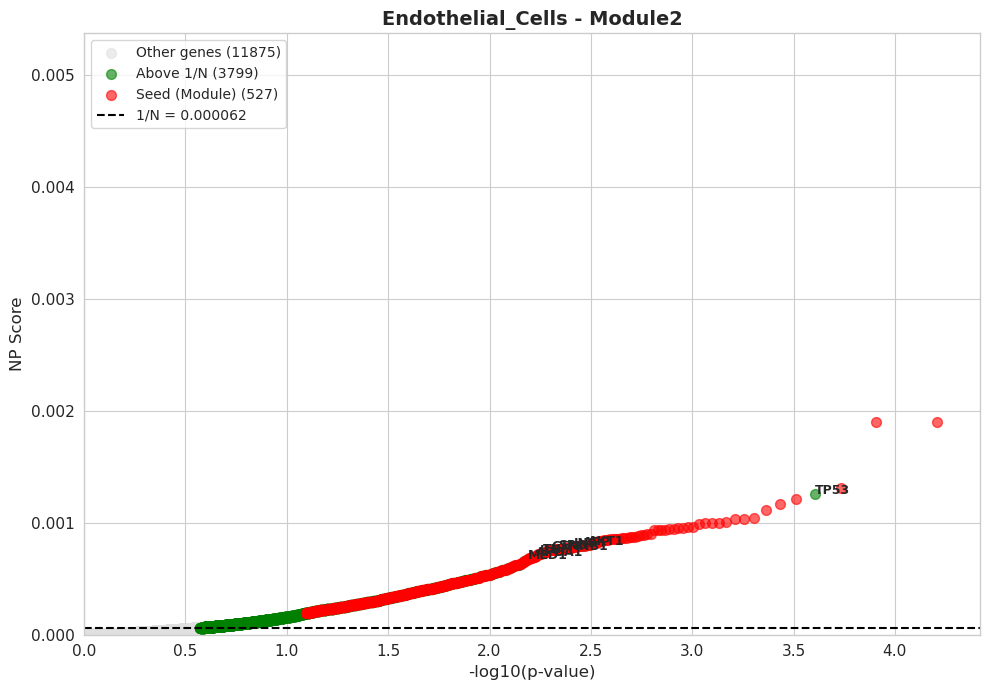

Module genes: 551 | in-network seeds: 527 | novel candidates (>=1/N): 3799
Top 20:
 Rank     Gene  NP_Score is_Seed
    1 TMEM176A  0.001898     Yes
    2 TMEM176B  0.001898     Yes
    3     EGFR  0.001309     Yes
    4     TP53  0.001257      No
    5   RPS27A  0.001216     Yes
    6      ALB  0.001172     Yes
    7    UBA52  0.001112     Yes
    8    RPS18  0.001041     Yes
    9      FAU  0.001036     Yes
   10     RPS3  0.001035     Yes
   11     ACTB  0.001005     Yes
   12    RPS11  0.001002     Yes
   13     MPC2  0.000998     Yes
   14      FN1  0.000996     Yes
   15     RPS9  0.000991     Yes
   16   RPL23A  0.000960     Yes
   17     RPS6  0.000959     Yes
   18     RPL5  0.000957     Yes
   19    RPS19  0.000954     Yes
   20    RPL11  0.000948     Yes


In [7]:
CT = 'Endothelial_Cells'
for mod in ['Module1', 'Module2']:
    print(f'\n{"-"*80}')
    plot_np(CT, mod)

---
## 7. Plasma_Cells


--------------------------------------------------------------------------------


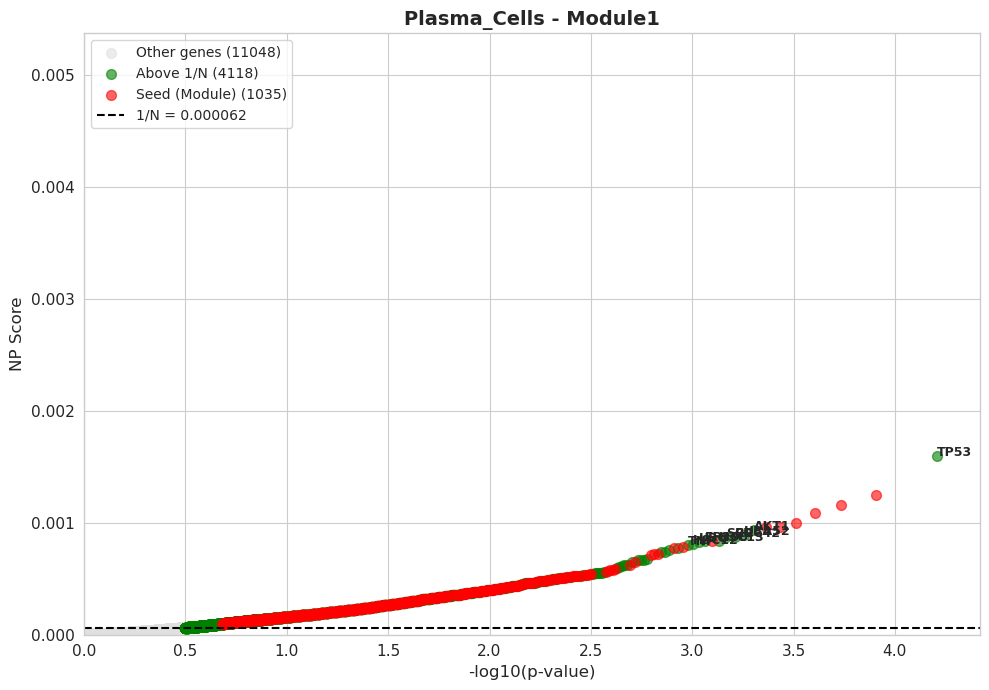

Module genes: 1103 | in-network seeds: 1035 | novel candidates (>=1/N): 4118
Top 20:
 Rank     Gene  NP_Score is_Seed
    1     TP53  0.001599      No
    2     EGFR  0.001250     Yes
    3   CTNNB1  0.001156     Yes
    4   RPS27A  0.001090     Yes
    5     ACTB  0.001000     Yes
    6 TMEM176B  0.000966     Yes
    7 TMEM176A  0.000966     Yes
    8     AKT1  0.000932      No
    9    UBA52  0.000886      No
   10    CDC42  0.000871      No
   11      SRC  0.000869      No
   12    H3C13  0.000839      No
   13     RHOA  0.000839     Yes
   14    EP300  0.000839      No
   15      UBC  0.000830      No
   16    H3C12  0.000809      No
   17      TNF  0.000799      No
   18      ALB  0.000784     Yes
   19    HDAC1  0.000775      No
   20      FN1  0.000773     Yes

--------------------------------------------------------------------------------


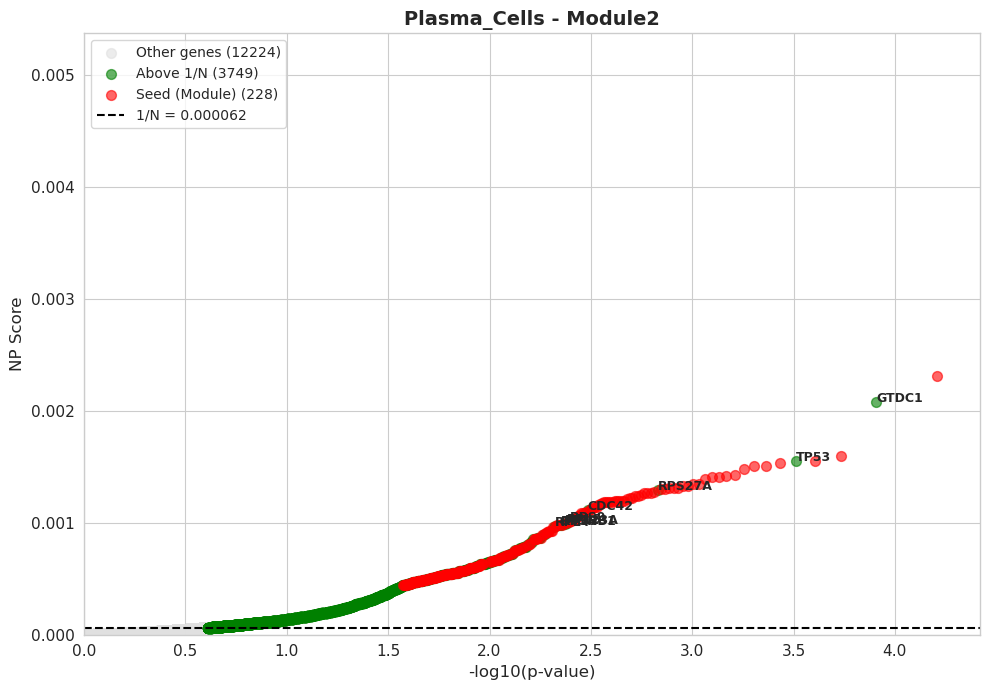

Module genes: 238 | in-network seeds: 228 | novel candidates (>=1/N): 3749
Top 20:
 Rank     Gene  NP_Score is_Seed
    1 ARHGAP15  0.002308     Yes
    2    GTDC1  0.002078      No
    3    UBA52  0.001599     Yes
    4    RPS18  0.001555     Yes
    5     TP53  0.001550      No
    6     RPS3  0.001538     Yes
    7      FAU  0.001510     Yes
    8    RPS11  0.001504     Yes
    9    RPS19  0.001481     Yes
   10    RPL11  0.001429     Yes
   11    RPL23  0.001419     Yes
   12    RPS23  0.001413     Yes
   13    RPS16  0.001407     Yes
   14    RPS15  0.001392     Yes
   15    RPS3A  0.001348     Yes
   16     RPS5  0.001343     Yes
   17    RPS14  0.001332     Yes
   18     RPL8  0.001331     Yes
   19     RPS8  0.001314     Yes
   20    RPS13  0.001307     Yes


In [8]:
CT = 'Plasma_Cells'
for mod in ['Module1', 'Module2']:
    print(f'\n{"-"*80}')
    plot_np(CT, mod)

---
## 8. DCs


--------------------------------------------------------------------------------


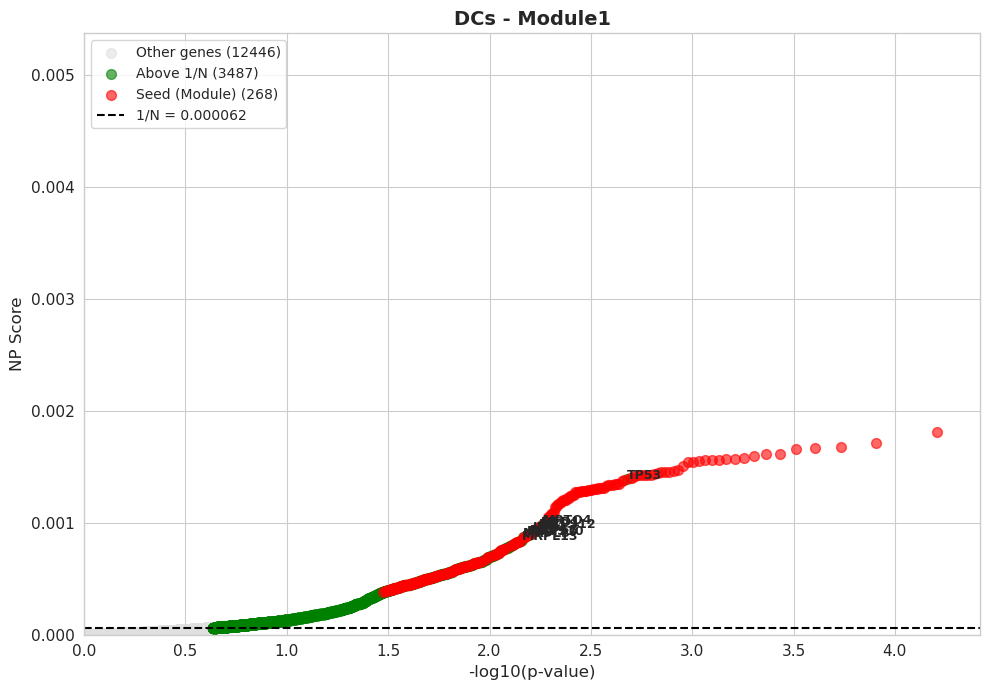

Module genes: 277 | in-network seeds: 268 | novel candidates (>=1/N): 3487
Top 20:
 Rank   Gene  NP_Score is_Seed
    1 RPS27A  0.001808     Yes
    2  RPS18  0.001709     Yes
    3   RPS3  0.001678     Yes
    4  UBA52  0.001666     Yes
    5  RPS11  0.001656     Yes
    6    FAU  0.001619     Yes
    7   RPS9  0.001612     Yes
    8  RPS19  0.001600     Yes
    9   RPL5  0.001583     Yes
   10  RPL11  0.001571     Yes
   11 RPL23A  0.001568     Yes
   12  RPS23  0.001564     Yes
   13   RPL4  0.001558     Yes
   14  RPS16  0.001557     Yes
   15  RPL23  0.001553     Yes
   16   RPS6  0.001546     Yes
   17   RPS2  0.001546     Yes
   18  RPS15  0.001511     Yes
   19   RPS5  0.001471     Yes
   20  RPS3A  0.001465     Yes

--------------------------------------------------------------------------------


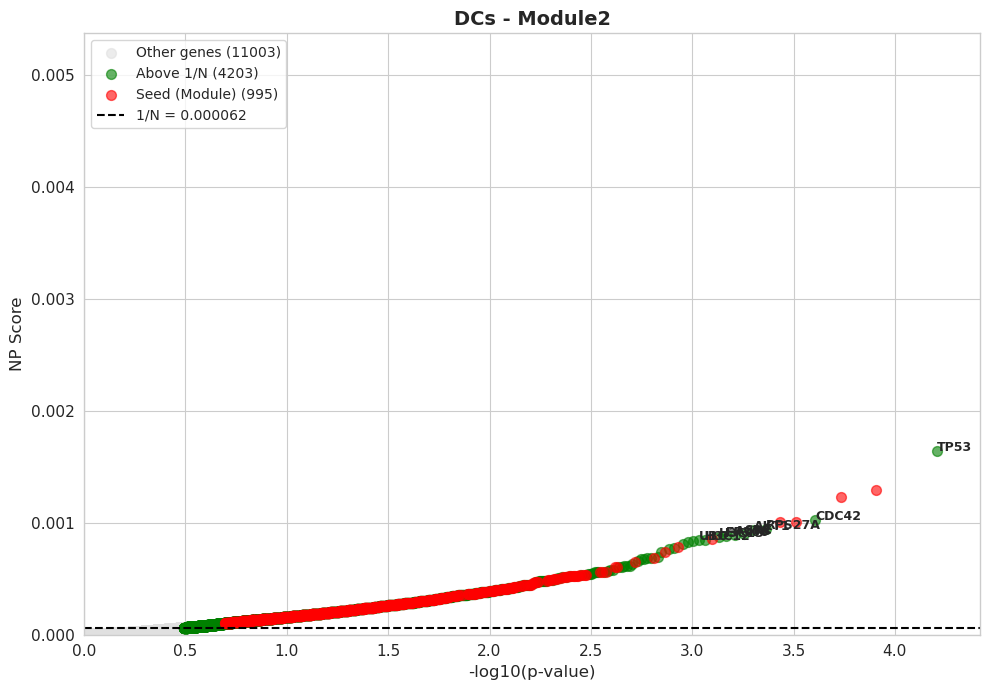

Module genes: 1064 | in-network seeds: 995 | novel candidates (>=1/N): 4203
Top 20:
 Rank     Gene  NP_Score is_Seed
    1     TP53  0.001643      No
    2     EGFR  0.001292     Yes
    3   CTNNB1  0.001233     Yes
    4    CDC42  0.001022      No
    5 TMEM176B  0.001005     Yes
    6 TMEM176A  0.001005     Yes
    7   RPS27A  0.000943      No
    8     AKT1  0.000939      No
    9      SRC  0.000901      No
   10     ACTB  0.000894      No
   11    EP300  0.000882      No
   12    H3C13  0.000873      No
   13     RHOA  0.000854     Yes
   14    H3C12  0.000845      No
   15      UBC  0.000842      No
   16    UBA52  0.000840      No
   17    HDAC1  0.000832      No
   18      TNF  0.000809      No
   19      FN1  0.000786     Yes
   20      MYC  0.000774      No


In [9]:
CT = 'DCs'
for mod in ['Module1', 'Module2']:
    print(f'\n{"-"*80}')
    plot_np(CT, mod)

---
## 9. B_Cells


--------------------------------------------------------------------------------


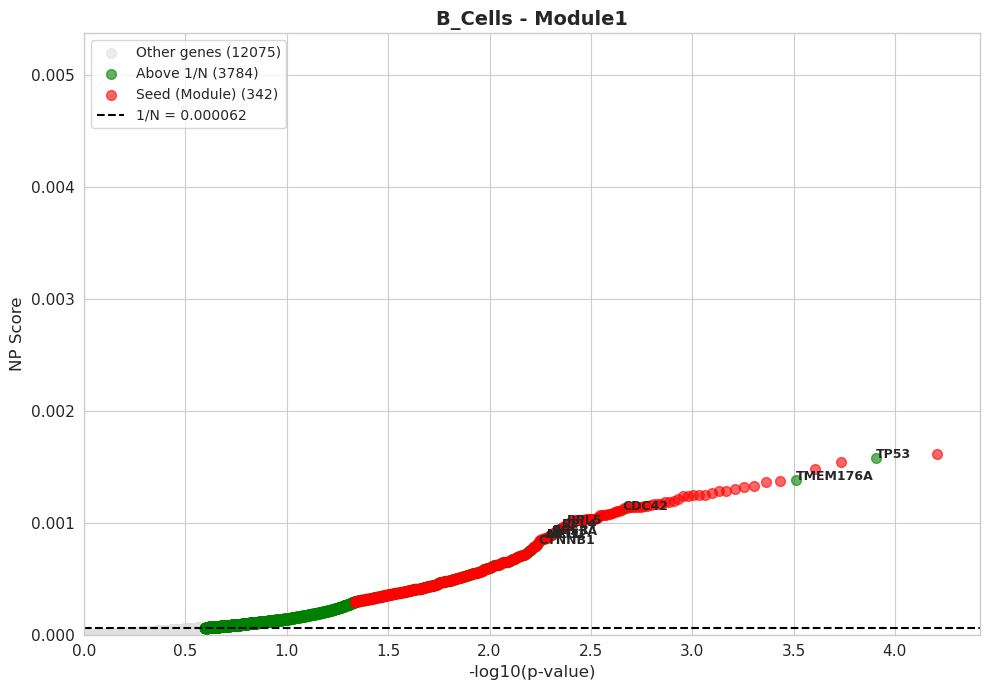

Module genes: 364 | in-network seeds: 342 | novel candidates (>=1/N): 3784
Top 20:
 Rank     Gene  NP_Score is_Seed
    1   RPS27A  0.001617     Yes
    2     TP53  0.001578      No
    3 TMEM176B  0.001539     Yes
    4    UBA52  0.001481     Yes
    5 TMEM176A  0.001385      No
    6    RPS18  0.001374     Yes
    7     RPS3  0.001366     Yes
    8    RPS11  0.001333     Yes
    9      FAU  0.001320     Yes
   10     RPS9  0.001306     Yes
   11   RPL23A  0.001286     Yes
   12     RPS6  0.001280     Yes
   13    RPL11  0.001267     Yes
   14    RPS23  0.001251     Yes
   15    RPL23  0.001251     Yes
   16     ACTB  0.001249     Yes
   17     RPS2  0.001240     Yes
   18    RPS16  0.001238     Yes
   19    RPS15  0.001216     Yes
   20    RPS19  0.001191     Yes

--------------------------------------------------------------------------------


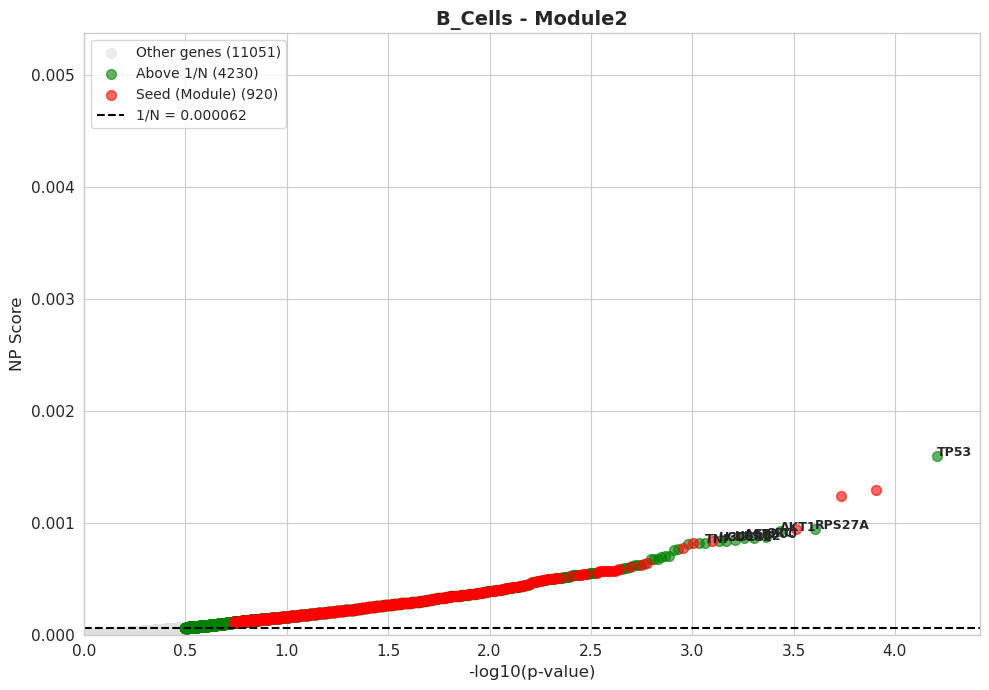

Module genes: 976 | in-network seeds: 920 | novel candidates (>=1/N): 4230
Top 20:
 Rank   Gene  NP_Score is_Seed
    1   TP53  0.001593      No
    2   EGFR  0.001290     Yes
    3 CTNNB1  0.001240     Yes
    4 RPS27A  0.000945      No
    5    UBC  0.000941     Yes
    6   AKT1  0.000924      No
    7    SRC  0.000874      No
    8  EP300  0.000863      No
    9   ACTB  0.000861      No
   10  UBA52  0.000842      No
   11  CDC42  0.000841      No
   12  H3C13  0.000837      No
   13    ALB  0.000836     Yes
   14    TNF  0.000822      No
   15  HDAC1  0.000822      No
   16    FN1  0.000816     Yes
   17  H3C12  0.000814      No
   18    APP  0.000778     Yes
   19    MYC  0.000764      No
   20   H4C6  0.000759      No


In [10]:
CT = 'B_Cells'
for mod in ['Module1', 'Module2']:
    print(f'\n{"-"*80}')
    plot_np(CT, mod)